# YOLOv8 Training Experiments (Analysis)

This notebook summarizes training experiments performed using pipeline scripts.

Note:
Training was executed separately due to high computational cost.

This notebook focuses on:
- Visualizing results
- Drawing insights

In [7]:
import os
import pandas as pd
import cv2
import random
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA_PATH = os.path.join(PROJECT_ROOT, "data", "helmet_detection")

RUNS_PATH = os.path.join(PROJECT_ROOT, "runs", "detect", "runs")

EXP_PATH = os.path.join(RUNS_PATH, "exp")

print("Experiment path:", EXP_PATH)
print("Exists:", os.path.exists(EXP_PATH))

Experiment path: /Users/monimoybharadwaj/Desktop/Helmet Detection/runs/detect/runs/exp
Exists: True


# Validation predictions

Available validation predictions: ['val_batch2_pred.jpg', 'val_batch1_pred.jpg', 'val_batch0_pred.jpg']


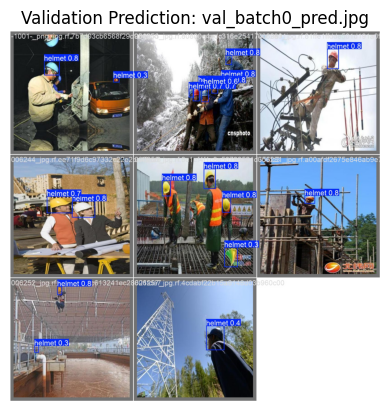

In [3]:
val_images = [f for f in os.listdir(EXP_PATH) if "val_batch" in f and "pred" in f]

print("Available validation predictions:", val_images)

img_name = random.choice(val_images)

img_path = os.path.join(EXP_PATH, img_name)

img = cv2.imread(img_path)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Validation Prediction: {img_name}")
plt.axis("off")
plt.show()

# Showing training batches

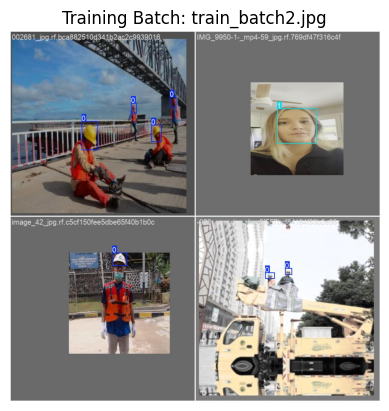

In [4]:
train_images = [f for f in os.listdir(EXP_PATH) if "train_batch" in f]

img_name = random.choice(train_images)

img_path = os.path.join(EXP_PATH, img_name)

img = cv2.imread(img_path)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Training Batch: {img_name}")
plt.axis("off")
plt.show()

# Reading metrics obatined from training the model

In [8]:
csv_path = os.path.join(EXP_PATH, "results.csv")

df = pd.read_csv(csv_path)

df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,3323.25,1.64965,1.43801,1.43507,0.70328,0.70487,0.73520,0.38649,1.60348,1.23795,1.41234,0.000333,0.000333,0.067010
1,2,5935.55,1.56144,1.21116,1.38053,0.80216,0.71525,0.78913,0.42014,1.57008,1.11996,1.39331,0.000601,0.000601,0.033944
2,3,8821.96,1.51516,1.11591,1.34678,0.81970,0.75934,0.81454,0.44984,1.52356,1.02274,1.36497,0.000802,0.000802,0.000812
3,4,11752.00,1.47475,1.03287,1.32604,0.81348,0.77913,0.82560,0.46320,1.49272,1.04033,1.33406,0.000703,0.000703,0.000703
4,5,14552.70,1.44104,0.97477,1.30234,0.82711,0.77725,0.83295,0.46924,1.49859,0.95476,1.33680,0.000604,0.000604,0.000604


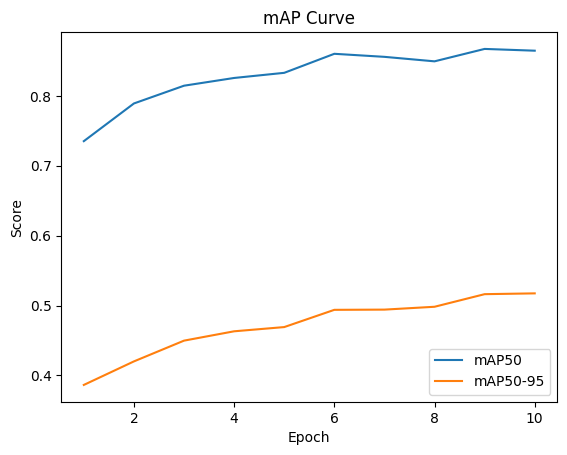

In [10]:
plt.figure()
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.legend()
plt.title("mAP Curve")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.show()

# Observations from mAP Curve

1. Both **mAP@50** and **mAP@50-95** increase rapidly from epoch 1 to ~5 indicating:
  - Model is learning meaningful features quickly  
  - Dataset is reasonably clean and well-annotated  

2. Gradual Saturation After Mid Training after ~epoch 6:
  - mAP50 plateaus around **0.85–0.87**
  - mAP50-95 stabilizes around **0.50–0.52**

This suggests:
  - Model is approaching **convergence**
  - Additional epochs give **diminishing returns**

3. Noticable gap Between mAP@50 and mAP50-95 indicating
  - Model detects objects well (loose IoU = 0.5)
  - But struggles with **precise bounding box localization**

4. No Overfitting Signal
  - No sharp drop in validation performance  
  - Curves remain stable  